In [1]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('/content/modified_placement_data.csv')

In [4]:
df.head()

,cgpa,iq,placement
0,"6,8",123.0,Yes
1,"5,9",106.0,No
2,"5,3",121.0,No
3,"7,4",132.0,Yes
4,"5,8",142.0,No


In [6]:
df.shape

(100, 3)

# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model
     

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       95 non-null     object 
 1   iq         100 non-null    float64
 2   placement  100 non-null    object 
dtypes: float64(1), object(2)
memory usage: 2.5+ KB


In [8]:
import matplotlib.pyplot as plt


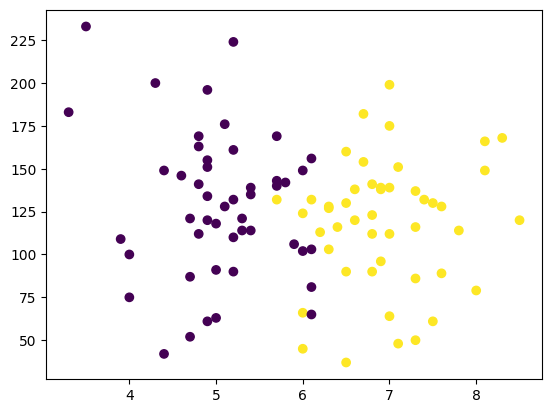

In [14]:
df['placement'] = df['placement'].map({'No':0,'Yes':1})
plt.scatter(df['cgpa'],df['iq'], c=df['placement'])

In [17]:
x = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [19]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [21]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1,random_state=2)

In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [24]:
# train model
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

# Impute NaN values in x_train_scaled before fitting the model
# Ideally, imputation should happen before scaling, but given the constraint
# to modify only this cell, we impute the already scaled data.
imputer = SimpleImputer(strategy='mean')
x_train_scaled_imputed = imputer.fit_transform(x_train_scaled)

model = LogisticRegression()
model.fit(x_train_scaled_imputed, y_train)

LogisticRegression()

In [25]:
model.predict(x_test_scaled)

array([1, 1, 1, 0, 0, 0, 0, 1, 0, 1])

In [26]:
y_test

,placement
83,1
30,1
56,0
24,0
16,0
23,0
2,0
27,1
28,0
13,1


In [27]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(x_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9


<Axes: >

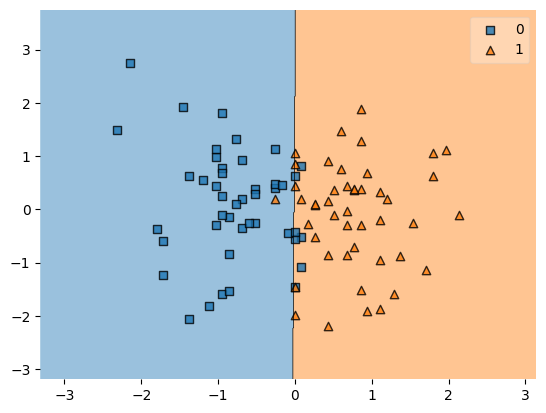

In [31]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X=x_train_scaled_imputed, y=y_train.values, clf=model)